### Set up GUI

In [5]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, clear_output
import numpy as np

class Game2048GUI:
    COLORS = {
        0:(205,193,180), 2:(238,228,218), 4:(237,224,200),
        8:(242,177,121), 16:(245,149,99), 32:(246,124,95),
        64:(246,94,59),  128:(237,207,114), 256:(237,204,97),
        512:(237,200,80), 1024:(237,197,63), 2048:(237,194,46),
    }
    ACTION_NAMES = {0:"↑ UP", 1:"→ RIGHT", 2:"↓ DOWN", 3:"← LEFT"}

    def __init__(self, size=4, speed=0.0, **kwargs):
        self.size    = size
        self.speed   = speed
        self._closed = False
        self._step   = 0
        self._score  = 0
        self._illegal_count = 0

    def update(self, board, info, action=None):
        if self._closed:
            return

        board = np.array(board)
        if "board" in info:
            b = np.array(info["board"])
            if b.shape == (self.size, self.size):
                board = b
        elif board.ndim == 3:
            board = board[:,:,0] if board.shape[2]==1 else np.argmax(board, axis=-1)
        elif board.ndim == 1:
            n = self.size
            D = board.shape[0] // (n*n)
            board = board.reshape(n,n) if D==1 else np.argmax(board.reshape(n,n,D), axis=-1)
        board = board.astype(int)

        self._step  += 1
        is_legal     = info.get("is_legal", True)
        if not is_legal:
            self._illegal_count += 1
        self._score  = info.get("total_score", self._score)
        max_pow      = info.get("max", 0)
        max_tile     = 2 ** max_pow if max_pow > 0 else 0

        fig, ax = plt.subplots(figsize=(4.5, 5))
        fig.patch.set_facecolor("#faf8ef")
        ax.set_facecolor("#bbada0")
        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_aspect("equal")
        ax.axis("off")

        for r in range(self.size):
            for c in range(self.size):
                val      = int(board[r, c])
                tile_val = 2**val if val > 0 else 0
                rgb      = self.COLORS.get(tile_val, (60,200,100))
                color    = tuple(x/255 for x in rgb)

                rect = patches.FancyBboxPatch(
                    (c+0.06, self.size-r-0.94), 0.88, 0.88,
                    boxstyle="round,pad=0.02",
                    facecolor=color, edgecolor="#bbada0", linewidth=2
                )
                ax.add_patch(rect)

                if tile_val > 0:
                    fg  = (0.47, 0.43, 0.40) if tile_val <= 4 else (0.98, 0.96, 0.95)
                    fs  = 18 if tile_val < 100 else (14 if tile_val < 1000 else 11)
                    ax.text(c+0.5, self.size-r-0.5, str(tile_val),
                            ha="center", va="center", fontsize=fs,
                            fontweight="bold", color=fg)

        action_str = self.ACTION_NAMES.get(action, "") if action is not None else ""
        legal_str  = "  ILLEGAL" if not is_legal else ""
        ax.set_title(
            f"Score: {int(self._score):,}   Max: {max_tile}   Steps: {self._step}\n"
            f"{action_str}{legal_str}",
            fontsize=10, color="#776e65", pad=8
        )

        clear_output(wait=True)
        display(fig)
        plt.close(fig)

    def set_status(self, text):
        print(text)

    def close(self):
        self._closed = True

    def wait_closed(self):
        pass

### Create Training Wrapper

In [6]:
%matplotlib inline
import gymnasium as gym
import gymnasium_2048
from stable_baselines3 import DQN
from stable_baselines3.common.logger import configure
import numpy as np

class TrainingWrapper(gym.Wrapper):
    def _process_obs(self, obs):
        safe_obs = np.maximum(obs, 1)
        return np.log2(safe_obs).astype(np.float32)
        
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._process_obs(obs), info
    
    def step(self, action):
        # Get current board state
        obs, reward, done, truncated, info = self.env.step(action)
        # log 2 scale for model computation
        obs = self._process_obs(obs)

        # Punish when stuck on illegal move
        if info['is_legal'] == False:
            reward += 5

        # Reward higher step_score
        added_score = info['step_score']
        if added_score > 0:
            reward += added_score

        # Keep higher tile in corner
        board_powers = np.argmax(obs, axis=-1) 
        max_power = np.max(board_powers)
        if (max_power == (board_powers[0,0] or board_powers[0,3] or 
            board_powers[3,0] or board_powers[3,3])):
            
            tile = 2 ** max_power
            reward += (tile * 0.1)

        return obs, reward, done, truncated, info

training_env = gym.make("gymnasium_2048:gymnasium_2048/TwentyFortyEight-v0", size=4, max_pow=11)
training_env = TrainingWrapper(training_env)

### Train Model

In [17]:
log_dir = "./training_logs/"
logger = configure(log_dir, ["csv"])

model = DQN(
    "MlpPolicy", 
    training_env, 
    learning_rate=1e-4,     
    buffer_size=100000,   
    learning_starts=1_000,  
    batch_size=32,
    gamma=0.99,
    policy_kwargs=dict(net_arch=[128, 128, 128, 128]),
    verbose=0
)

print("Training...")
model.set_logger(logger)
model.learn(total_timesteps=25000)
model.save("./trained_models/dqn_2048_mlp")



del model
model = DQN.load("./trained_models/dqn_2048_mlp")

print("Training finished.")

Training...
Training finished.


In [7]:
# Load trained model
# SKIP IF TRAINED ALREADY
model = DQN.load("./trained_models/corner")

### Training Graph

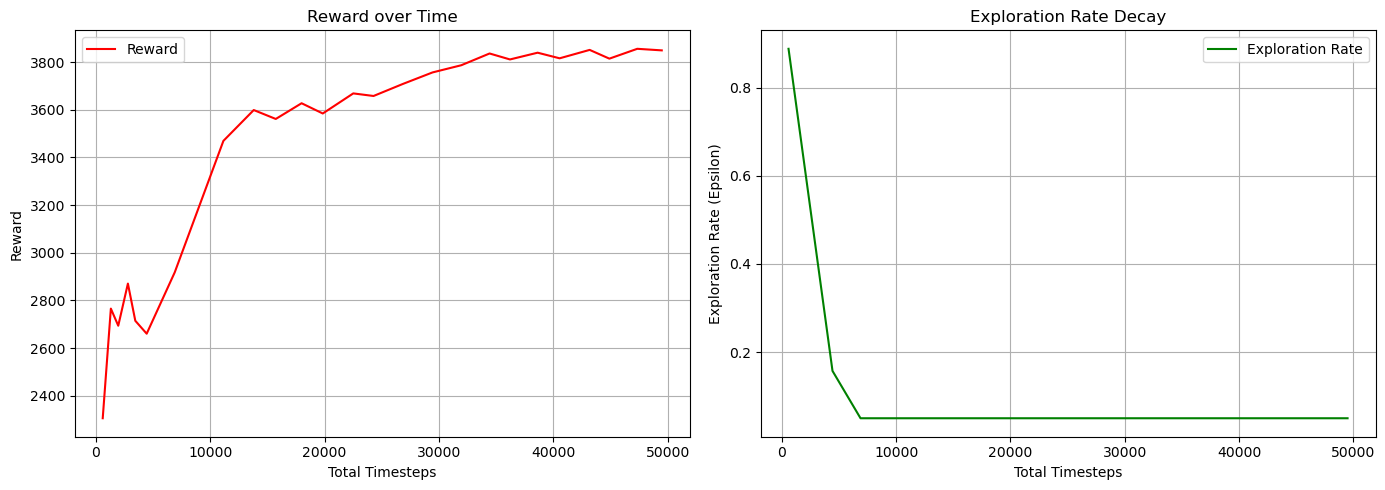

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os

log_file = "./training_logs/corner.csv" 

df = pd.read_csv(log_file)

# Create two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- GRAPH 1: Loss ---
# Note: Loss isn't recorded until 'learning_starts' finishes, so we must drop NaN values
loss_data = df.dropna(subset=['rollout/ep_rew_mean', 'time/total_timesteps'])
ax1.plot(loss_data['time/total_timesteps'], loss_data['rollout/ep_rew_mean'], color='red', label='Reward')
ax1.set_title('Reward over Time')
ax1.set_xlabel('Total Timesteps')
ax1.set_ylabel('Reward')
ax1.grid(True)
ax1.legend()
    
# --- GRAPH 2: Exploration Rate ---
exp_data = df.dropna(subset=['rollout/exploration_rate', 'time/total_timesteps'])
ax2.plot(exp_data['time/total_timesteps'], exp_data['rollout/exploration_rate'], color='green', label='Exploration Rate')
ax2.set_title('Exploration Rate Decay')
ax2.set_xlabel('Total Timesteps')
ax2.set_ylabel('Exploration Rate (Epsilon)')
ax2.grid(True)
ax2.legend()

# Display the graphs neatly
plt.tight_layout()
plt.show()

### Test Game

In [7]:
# Create testing environment
def test_main():
    raw_env = gym.make("gymnasium_2048:gymnasium_2048/TwentyFortyEight-v0", size=4, max_pow=11)
    testing_env = TrainingWrapper(raw_env)
    obs, _ = testing_env.reset()
    done = False
    # gui = Game2048GUI(speed=0.0)
    
    print("Starting testing.")
    while not done:
        testing_env.render()
        
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = testing_env.step(action)
        # gui.update(obs, info, action=int(action))
        
        if info['max'] == 11:
            print("2048 reached!\n")
            break
        if info['is_legal'] == False:
            action = testing_env.action_space.sample()
            obs, reward, terminated, truncated, info = testing_env.step(action)
        
        done = terminated or truncated
        # Watch progress
        # print(info)
    
    # Print final board state and maximum tile

    final_max = 2**info['max']
    final_score = info['total_score']
    # print(f"{info['board']}\nMax = {2**info['max']}")
    # print("Game Over")
    testing_env.close()
    return final_max, final_score

In [8]:
print(test_main())

Starting testing.
(128, 1132)


In [10]:
import time
import pandas as pd

num_games = 20
results = []

print(f"Starting evaluation over {num_games} games...")

for i in range(num_games):
    start_time = time.time()
    
    # Run the game
    max_tile, score = test_main()
    
    end_time = time.time()
    time_taken = end_time - start_time
    
    # Save the stats for this specific game
    results.append({
        "Game_Number": i + 1,
        "Max_Tile": max_tile,
        "Final_Score": score,
        "Time_Taken_Sec": round(time_taken, 3)
    })
    
    print(f"Game {i+1}/{num_games} | Tile: {max_tile} | Score: {score} | Time: {round(time_taken, 2)}s")

# Convert our list of results into a Pandas DataFrame and save to CSV
df = pd.DataFrame(results)
csv_path = "./testing_results.csv"
df.to_csv(csv_path, index=False)
print("Done and saved.\n")

Starting evaluation over 20 games...
Starting testing.
Game 1/20 | Tile: 128 | Score: 1592 | Time: 0.15s
Starting testing.
Game 2/20 | Tile: 128 | Score: 1460 | Time: 0.14s
Starting testing.
Game 3/20 | Tile: 128 | Score: 1736 | Time: 0.17s
Starting testing.
Game 4/20 | Tile: 32 | Score: 556 | Time: 0.08s
Starting testing.
Game 5/20 | Tile: 128 | Score: 1464 | Time: 0.14s
Starting testing.
Game 6/20 | Tile: 128 | Score: 1204 | Time: 0.13s
Starting testing.
Game 7/20 | Tile: 256 | Score: 2644 | Time: 0.23s
Starting testing.
Game 8/20 | Tile: 64 | Score: 676 | Time: 0.07s
Starting testing.
Game 9/20 | Tile: 64 | Score: 1276 | Time: 0.15s
Starting testing.
Game 10/20 | Tile: 64 | Score: 740 | Time: 0.1s
Starting testing.
Game 11/20 | Tile: 256 | Score: 2332 | Time: 0.18s
Starting testing.
Game 12/20 | Tile: 64 | Score: 704 | Time: 0.09s
Starting testing.
Game 13/20 | Tile: 128 | Score: 1048 | Time: 0.1s
Starting testing.
Game 14/20 | Tile: 128 | Score: 1404 | Time: 0.15s
Starting testing.

### Graph Game Results

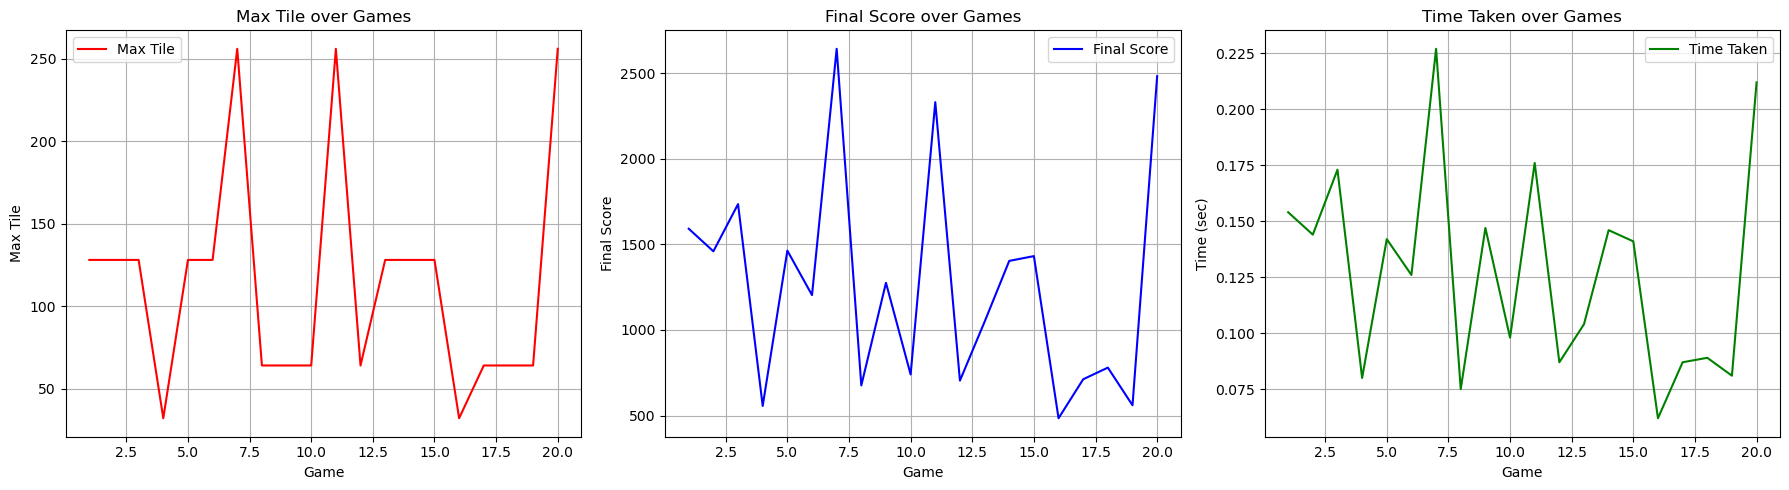

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import os

log_file = "./testing_results.csv" 

df = pd.read_csv(log_file)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- GRAPH 1: Max Tile ---
tile_data = df.dropna(subset=['Max_Tile', 'Game_Number'])
ax1.plot(tile_data['Game_Number'], tile_data['Max_Tile'], color='red', label='Max Tile')
ax1.set_title('Max Tile over Games')
ax1.set_xlabel('Game')
ax1.set_ylabel('Max Tile')
ax1.grid(True)
ax1.legend()
    
# --- GRAPH 2: Score ---
score_data = df.dropna(subset=['Final_Score', 'Game_Number'])
ax2.plot(score_data['Game_Number'], score_data['Final_Score'], color='blue', label='Final Score')
ax2.set_title('Final Score over Games')
ax2.set_xlabel('Game')
ax2.set_ylabel('Final Score')
ax2.grid(True)
ax2.legend()

# --- GRAPH 3: Time ---
time_data = df.dropna(subset=['Time_Taken_Sec', 'Game_Number'])
ax3.plot(time_data['Game_Number'], time_data['Time_Taken_Sec'], color='green', label='Time Taken')
ax3.set_title('Time Taken over Games')
ax3.set_xlabel('Game')
ax3.set_ylabel('Time (sec)')
ax3.grid(True)
ax3.legend()

# Display the graphs neatly
plt.tight_layout()
plt.show()

